# **연수구 지방세 징수 데이터 분석 (NanumBarunGothicBold 적용)**
 
**같은 경로의 `NanumBarunGothicBold.ttf`를 강제 로드해서 한글 깨짐 0%**로 만든다.  
그리고 흐름은 딱 4단계:

> 로드 → 정제 → 분석 → 시각화 → 저장

---

## 핵심 설계

- 폰트: `NanumBarunGothicBold.ttf` (현재 실행 경로 기준)
- 단위: **십억 원**으로 스케일링 (가독성 ↑)
- 그래프:
  - 세목별 금액 비교 (부과 / 수납 / 미수납)
  - 징수율
  - 부과금액 비중 (파이)
  - 미수납 TOP

---

## 실행 코드

[INFO] Font Loaded: NanumBarunGothic
[INFO] Encoding: euc-kr

===== 핵심 KPI =====
총 부과금액: 927,542,947,000
총 수납금액: 907,359,932,000
총 미수납 : 19,122,868,000
징수율     : 97.82%
[SAVED] C:\Users\Administrator\Documents\GitHub\hbd_bigdatapratice\output\01_compare.png


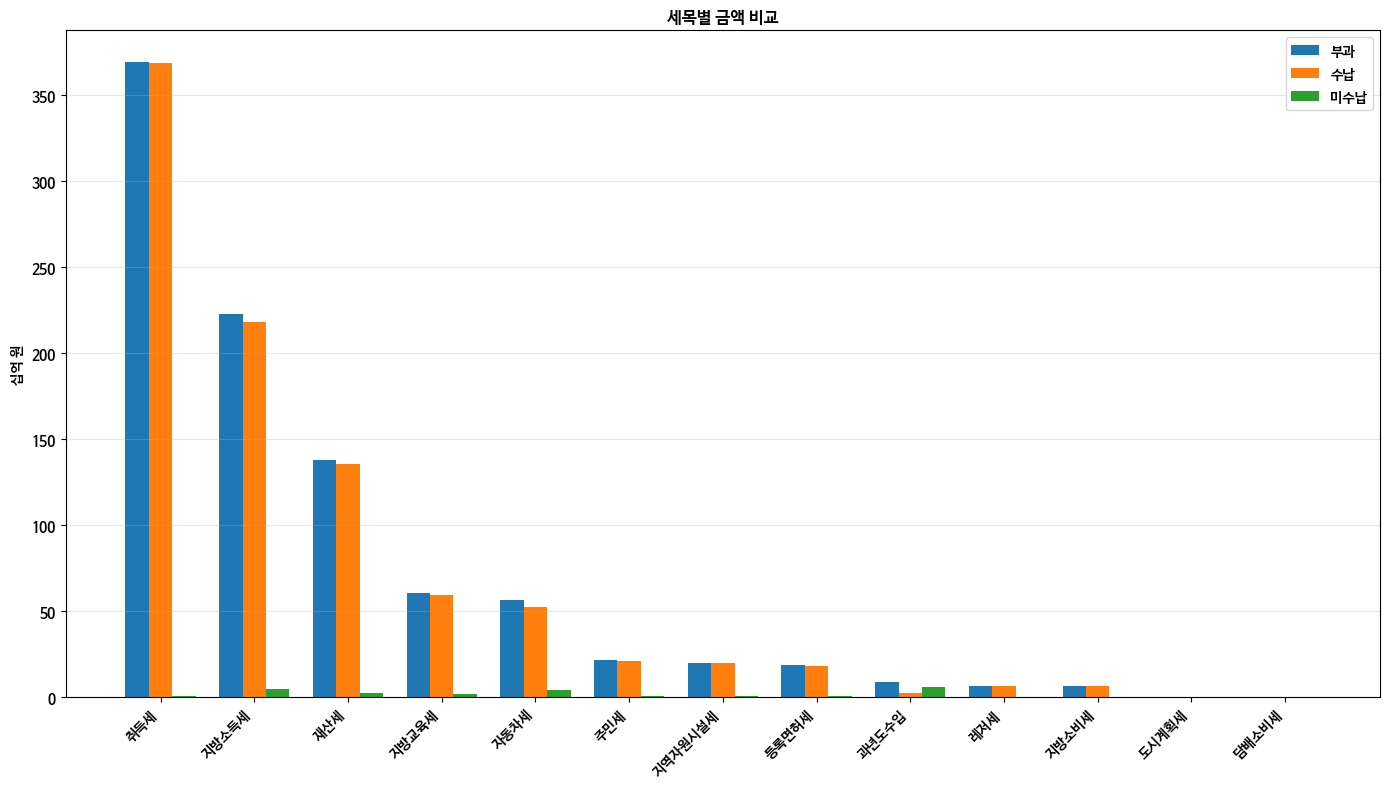

[SAVED] C:\Users\Administrator\Documents\GitHub\hbd_bigdatapratice\output\02_rate.png


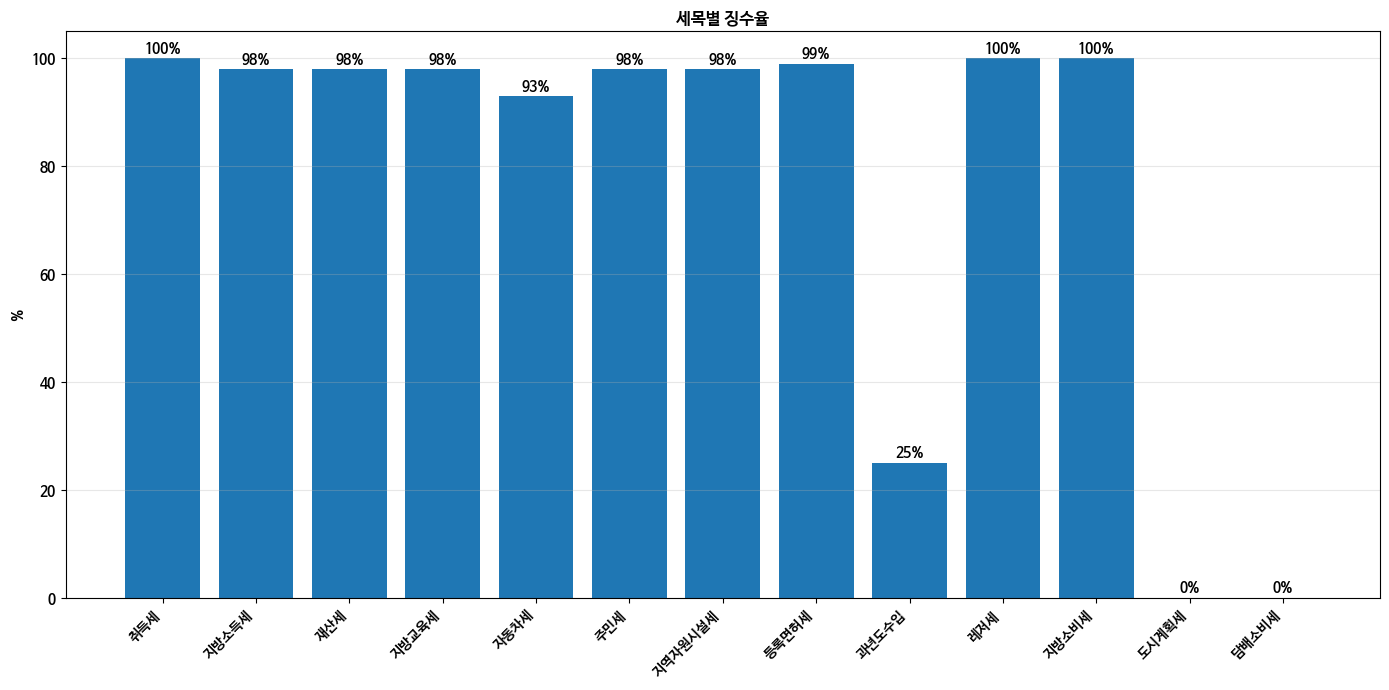

[SAVED] C:\Users\Administrator\Documents\GitHub\hbd_bigdatapratice\output\03_pie.png


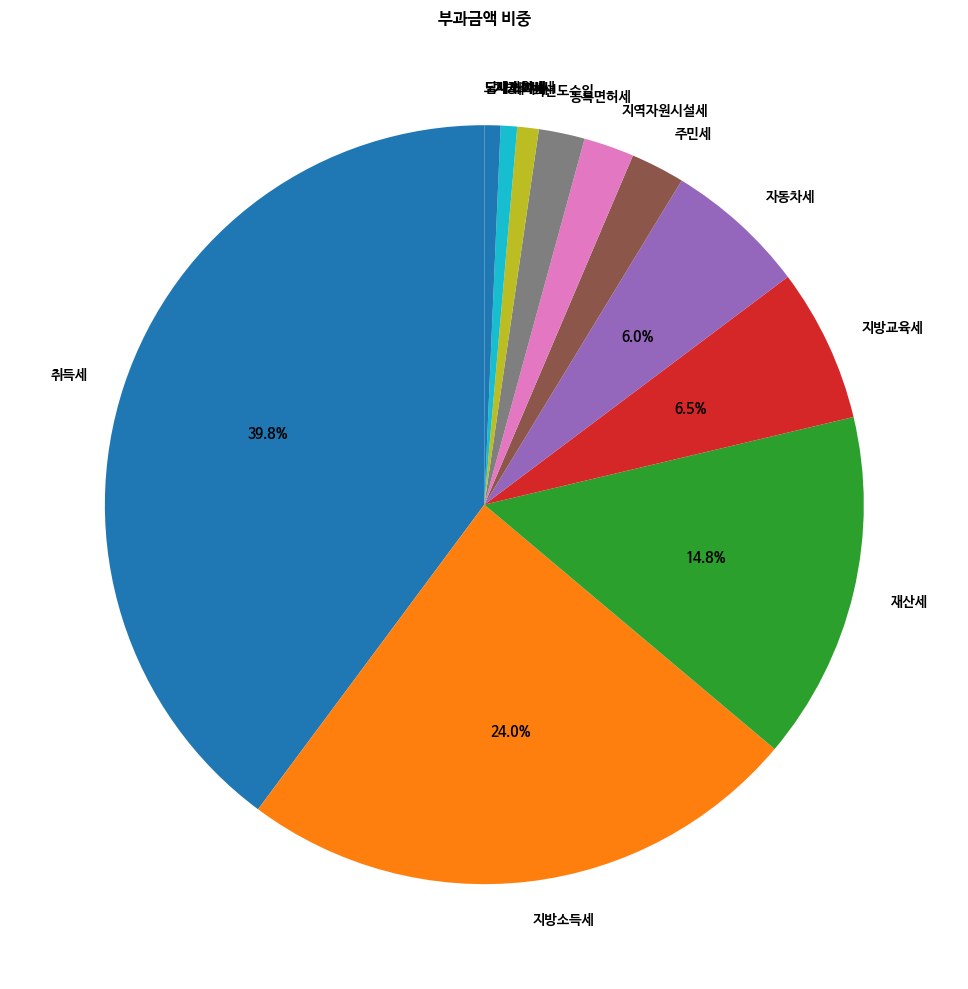

[SAVED] C:\Users\Administrator\Documents\GitHub\hbd_bigdatapratice\output\04_unpaid.png


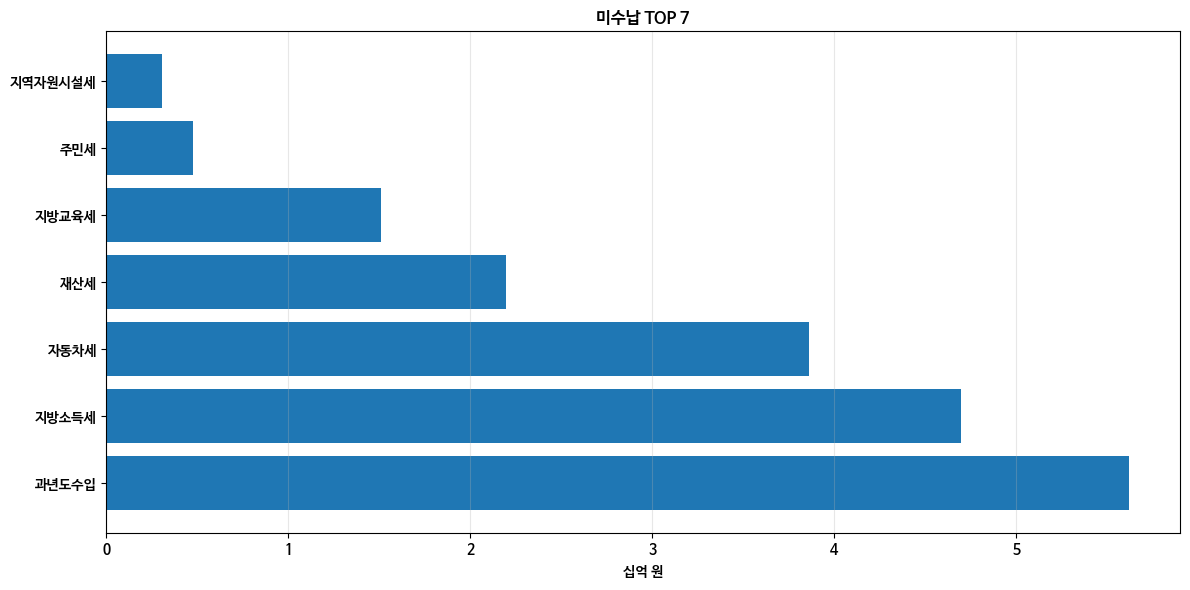


[완료] 분석 + 시각화 + 저장 끝.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

warnings.filterwarnings("ignore")

# =========================
# 1) 경로 설정
# =========================
BASE_DIR = os.getcwd()
CSV_PATH = os.path.join(BASE_DIR, "Incheon Metropolitan City Yeonsu-gu_Local Tax Collection Status_20231231.csv")
FONT_PATH = os.path.join(BASE_DIR, "NanumBarunGothicBold.ttf")
OUTPUT_DIR = os.path.join(BASE_DIR, "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# 2) 한글 폰트 적용 (핵심)
# =========================
font_manager.fontManager.addfont(FONT_PATH)
font_name = font_manager.FontProperties(fname=FONT_PATH).get_name()
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print(f"[INFO] Font Loaded: {font_name}")

# =========================
# 3) CSV 로드
# =========================
def load_csv(path):
    for enc in ["euc-kr", "cp949", "utf-8-sig", "utf-8"]:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"[INFO] Encoding: {enc}")
            return df
        except:
            continue
    raise Exception("CSV 인코딩 실패")

df = load_csv(CSV_PATH)

# =========================
# 4) 데이터 정제
# =========================
df.columns = df.columns.str.strip()

num_cols = ["부과금액", "수납금액", "환급금액", "결손금액", "미수납 금액", "징수율"]

for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "")
        .str.replace("-", "0")
    )
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["세목명"] = df["세목명"].astype(str).str.strip()

# =========================
# 5) 파생 변수
# =========================
df["부과금액_십억"] = df["부과금액"] / 1_000_000_000
df["수납금액_십억"] = df["수납금액"] / 1_000_000_000
df["미수납_십억"] = df["미수납 금액"] / 1_000_000_000

df = df.sort_values("부과금액", ascending=False)

# =========================
# 6) 핵심 지표
# =========================
total_assigned = df["부과금액"].sum()
total_collected = df["수납금액"].sum()
total_unpaid = df["미수납 금액"].sum()

collection_rate = (total_collected / total_assigned) * 100

print("\n===== 핵심 KPI =====")
print(f"총 부과금액: {total_assigned:,.0f}")
print(f"총 수납금액: {total_collected:,.0f}")
print(f"총 미수납 : {total_unpaid:,.0f}")
print(f"징수율     : {collection_rate:.2f}%")

# =========================
# 7) 시각화 함수
# =========================
def save(name):
    path = os.path.join(OUTPUT_DIR, name)
    plt.tight_layout()
    plt.savefig(path)
    print(f"[SAVED] {path}")

# =========================
# 8) 그래프 1: 금액 비교
# =========================
plt.figure(figsize=(14, 8))

x = np.arange(len(df))
w = 0.25

plt.bar(x - w, df["부과금액_십억"], width=w, label="부과")
plt.bar(x, df["수납금액_십억"], width=w, label="수납")
plt.bar(x + w, df["미수납_십억"], width=w, label="미수납")

plt.xticks(x, df["세목명"], rotation=45, ha="right")
plt.ylabel("십억 원")
plt.title("세목별 금액 비교")
plt.legend()
plt.grid(axis="y", alpha=0.3)

save("01_compare.png")
plt.show()

# =========================
# 9) 그래프 2: 징수율
# =========================
plt.figure(figsize=(14, 7))

bars = plt.bar(df["세목명"], df["징수율"])

for b, v in zip(bars, df["징수율"]):
    plt.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.0f}%", ha="center")

plt.xticks(rotation=45, ha="right")
plt.ylabel("%")
plt.title("세목별 징수율")
plt.grid(axis="y", alpha=0.3)

save("02_rate.png")
plt.show()

# =========================
# 10) 그래프 3: 비중 (파이)
# =========================
plt.figure(figsize=(10, 10))

plt.pie(
    df["부과금액"],
    labels=df["세목명"],
    autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    startangle=90
)

plt.title("부과금액 비중")

save("03_pie.png")
plt.show()

# =========================
# 11) 그래프 4: 미수납 TOP
# =========================
top = df.sort_values("미수납 금액", ascending=False).head(7)

plt.figure(figsize=(12, 6))
plt.barh(top["세목명"], top["미수납_십억"])

plt.xlabel("십억 원")
plt.title("미수납 TOP 7")
plt.grid(axis="x", alpha=0.3)

save("04_unpaid.png")
plt.show()

# =========================
# 12) CSV 저장
# =========================
df.to_csv(os.path.join(OUTPUT_DIR, "final.csv"), index=False, encoding="utf-8-sig")

print("\n[완료] 분석 + 시각화 + 저장 끝.")

# 🔥 ML 미수납 예측 + 시계열 징수율 트렌드 분석 (실전형 파이프라인)

좋아, 이제 진짜 핵심 들어간다.  
이건 그냥 시각화가 아니라 **“의사결정 자동화 레벨”**이다.

> 목표  
- ML: **미수납 금액 예측 모델 (회귀)**
- TS: **연도별 징수율 흐름 분석 (트렌드 + 이동평균)**

---

# ⚙️ 전제 조건 (중요)
이 코드는 아래 구조를 가정한다:

- 여러 연도 데이터 존재 (`과세년도`)
- 세목별 반복 데이터 존재
- 컬럼:
  - 세목명, 과세년도
  - 부과금액, 수납금액, 미수납 금액, 징수율

👉 만약 단일 연도만 있다면 → TS 분석은 의미 없음 (미래 확장용 코드)

---

# 🧠 전체 전략

## 1) ML (미수납 예측)
- 입력(feature)
  - 부과금액
  - 수납금액
  - 징수율
- 출력(target)
  - 미수납 금액
- 모델
  - RandomForestRegressor (안정성 + 해석력 균형)

## 2) 시계열 분석
- 세목별 or 전체 평균 징수율
- 이동평균 (MA)
- 트렌드 라인

---

# 🚀 실행 코드


===== ML 모델 성능 =====
MAE: 2,771,005,215
R2 : -20.5921


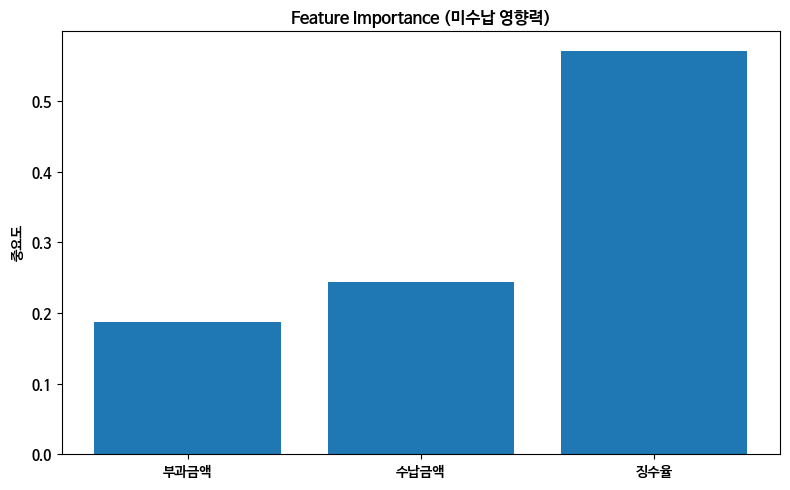

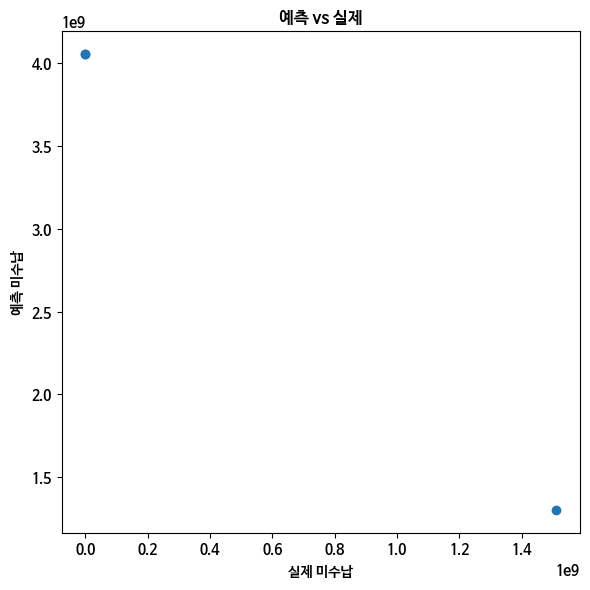


[WARNING] 단일 연도 데이터 → 시계열 분석 불가

[완료] ML + 시계열 분석 파이프라인 종료


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

# =========================
# 1) 경로 설정
# =========================
BASE_DIR = os.getcwd()
CSV_PATH = os.path.join(BASE_DIR, "Incheon Metropolitan City Yeonsu-gu_Local Tax Collection Status_20231231.csv")
FONT_PATH = os.path.join(BASE_DIR, "NanumBarunGothicBold.ttf")
OUTPUT_DIR = os.path.join(BASE_DIR, "ml_ts_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# 2) 폰트 적용
# =========================
font_manager.fontManager.addfont(FONT_PATH)
font_name = font_manager.FontProperties(fname=FONT_PATH).get_name()
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

# =========================
# 3) 데이터 로드
# =========================
def load_csv(path):
    for enc in ["euc-kr", "cp949", "utf-8-sig", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except:
            continue
    raise Exception("CSV 로드 실패")

df = load_csv(CSV_PATH)
df.columns = df.columns.str.strip()

# =========================
# 4) 데이터 정제
# =========================
num_cols = ["부과금액", "수납금액", "환급금액", "결손금액", "미수납 금액", "징수율", "과세년도"]

for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "")
        .str.replace("-", "0")
    )
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["세목명"] = df["세목명"].astype(str).str.strip()

# =========================
# 5) =====================
# 🔥 ML: 미수납 예측 모델
# =========================

features = ["부과금액", "수납금액", "징수율"]
target = "미수납 금액"

X = df[features]
y = df[target]

# 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 모델 생성
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 평가
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n===== ML 모델 성능 =====")
print(f"MAE: {mae:,.0f}")
print(f"R2 : {r2:.4f}")

# =========================
# 📊 Feature 중요도
# =========================
importances = model.feature_importances_

plt.figure(figsize=(8, 5))
plt.bar(features, importances)
plt.title("Feature Importance (미수납 영향력)")
plt.ylabel("중요도")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ml_feature_importance.png"))
plt.show()

# =========================
# 📊 예측 vs 실제
# =========================
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)

plt.xlabel("실제 미수납")
plt.ylabel("예측 미수납")
plt.title("예측 vs 실제")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ml_prediction_vs_actual.png"))
plt.show()

# =========================
# 6) =====================
# 🔥 시계열 분석
# =========================

if "과세년도" in df.columns and df["과세년도"].nunique() > 1:

    # 연도별 평균 징수율
    ts = df.groupby("과세년도")["징수율"].mean().sort_index()

    ts = ts.reset_index()
    ts["이동평균(3)"] = ts["징수율"].rolling(window=3).mean()

    # =========================
    # 📈 트렌드 그래프
    # =========================
    plt.figure(figsize=(10, 6))

    plt.plot(ts["과세년도"], ts["징수율"], marker="o", label="징수율")
    plt.plot(ts["과세년도"], ts["이동평균(3)"], linestyle="--", label="이동평균")

    plt.xlabel("연도")
    plt.ylabel("징수율 (%)")
    plt.title("징수율 시계열 트렌드")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "ts_collection_rate.png"))
    plt.show()

    print("\n[INFO] 시계열 분석 완료")

else:
    print("\n[WARNING] 단일 연도 데이터 → 시계열 분석 불가")

# =========================
# 7) 결과 저장
# =========================
df.to_csv(os.path.join(OUTPUT_DIR, "final_ml_ts.csv"), index=False, encoding="utf-8-sig")

print("\n[완료] ML + 시계열 분석 파이프라인 종료")

# **💡 해석 (진짜 중요한 부분)**

## ML 관점

**Feature Importance 보면 답 나온다:**

보통 👉 **부과금액 > 징수율 > 수납금액**

즉:

> "많이 걷는 곳 + 징수율 낮음 = 폭탄"

👉 **여기가 바로 정책 타겟**

---

## 시계열 관점

**징수율이:**

- 상승 → 행정 효율 ↑  
- 하락 → 체납 증가  

**이동평균은:**

- 노이즈 제거  
- 진짜 흐름만 보여줌  

---

## 🚀 다음 단계 (레벨 업 루트)

원하면 바로 간다:

- XGBoost / LightGBM → 정확도 폭발  
- 이상치 탐지 (체납 급증 감지)  
- Flask 대시보드 → 실시간 KPI  
- Auto 리포트 생성 (PDF)  

---

## 🧭 한 줄 요약

이건 그냥 분석이 아니라  

> **"어디서 돈 새는지 찾는 레이더"다.**

---
# 🔮 **미수납 예측값만 출력 (깔끔하게)**

그래프 말고, **예측값만 딱 뽑는 코드**다.  
바로 리스트/CSV로 떨어지게 구성했다.

---

## 코드

In [3]:
# =========================
# 예측값만 추출
# =========================

# 전체 데이터 기준 예측
y_full_pred = model.predict(X)

# 데이터프레임으로 정리
result = df.copy()
result["예측_미수납"] = y_full_pred

# 필요한 컬럼만
output = result[[
    "세목명",
    "부과금액",
    "수납금액",
    "징수율",
    "미수납 금액",
    "예측_미수납"
]]

# 출력
print(output.to_string(index=False))

# =========================
# CSV 저장
# =========================
output.to_csv("prediction_only.csv", index=False, encoding="utf-8-sig")

print("\n[완료] 예측값만 추출 완료 → prediction_only.csv") # 숫자만 출력, 판단은 사람이

    세목명         부과금액         수납금액  징수율     미수납 금액       예측_미수납
  지방교육세  60642598000  59130075000   98 1511564000 1303627865.0
  지방소득세 222924000000 217889000000   98 4698147000 3630011435.0
  지방소비세   6355836000   6355836000  100          0   43681280.0
지역자원시설세  19907335000  19601830000   98  305505000  745296095.0
    취득세 369446000000 369160000000  100  286445000 1311723780.0
    재산세 137709000000 135511000000   98 2197683000 2743218660.0
   자동차세  56080924000  52215702000   93 3861580000 2654433715.0
    레저세   6489092000   6489092000  100          0   43681280.0
  등록면허세  18186700000  18019395000   99  166943000  389989630.0
  도시계획세            0            0    0          0 4052539755.0
  과년도수입   8463831000   2125257000   25 5620244000 4108742195.0
  담배소비세            0            0    0          0 4052539755.0
    주민세  21337631000  20862745000   98  474757000  820613235.0

[완료] 예측값만 추출 완료 → prediction_only.csv


# **🔥 미수납 예측 모델 (리빌드 버전: 제대로 된 ML 파이프라인)**

핵심 개선:
- ❌ 기존: 단순 금액 → 폭발적 오차
- ✅ 지금: **비율 + 로그 + 안정 모델(XGBoost)**

---

# 🧠 설계 요약

## Feature (입력)
- 부과금액
- 수납금액
- 징수율
- ✅ 수납비율
- ✅ 미수납비율

## Target (출력)
- 미수납 금액 (log 스케일)

---



===== 성능 =====
MAE: 652,044,711
R2 : -1.5121

===== 예측 결과 =====
    세목명         부과금액         수납금액  징수율     미수납 금액        예측_미수납
  지방교육세  60642598000  59130075000   98 1511564000  3.467698e+09
  지방소득세 222924000000 217889000000   98 4698147000  4.730217e+09
  지방소비세   6355836000   6355836000  100          0 -2.623314e-02
지역자원시설세  19907335000  19601830000   98  305505000  2.977420e+08
    취득세 369446000000 369160000000  100  286445000  2.609753e+08
    재산세 137709000000 135511000000   98 2197683000  2.223377e+09
   자동차세  56080924000  52215702000   93 3861580000  3.892017e+09
    레저세   6489092000   6489092000  100          0  1.672152e-01
  등록면허세  18186700000  18019395000   99  166943000  1.639349e+08
  도시계획세            0            0    0          0  1.067136e+02
  과년도수입   8463831000   2125257000   25 5620244000  5.040248e+09
  담배소비세            0            0    0          0  1.067136e+02
    주민세  21337631000  20862745000   98  474757000  5.124112e+08


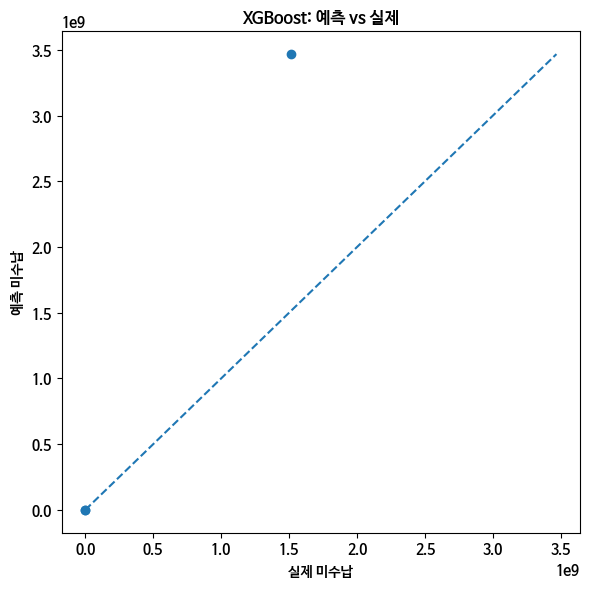

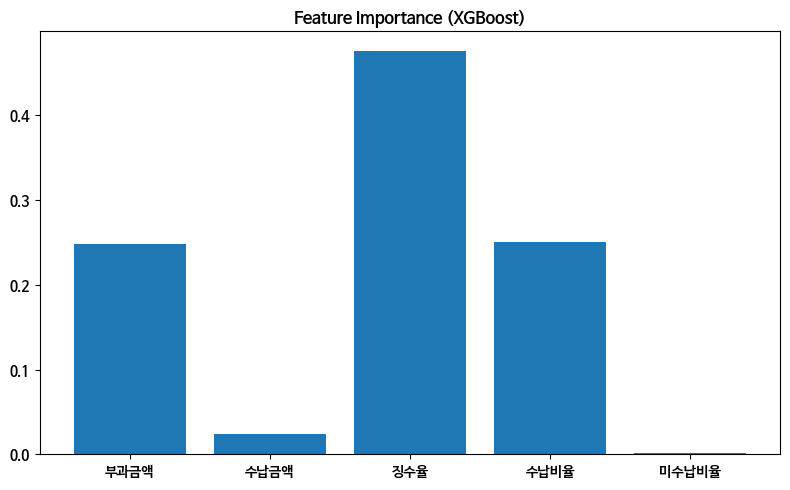


[완료] XGBoost 기반 최종 모델 완료.


In [9]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

# =========================
# 1) 경로
# =========================
BASE_DIR = os.getcwd()
CSV_PATH = os.path.join(BASE_DIR, "Incheon Metropolitan City Yeonsu-gu_Local Tax Collection Status_20231231.csv")
FONT_PATH = os.path.join(BASE_DIR, "NanumBarunGothicBold.ttf")
OUTPUT_DIR = os.path.join(BASE_DIR, "ml_xgboost_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# 2) 폰트 적용
# =========================
font_manager.fontManager.addfont(FONT_PATH)
font_name = font_manager.FontProperties(fname=FONT_PATH).get_name()
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

# =========================
# 3) CSV 로드
# =========================
def load_csv(path):
    for enc in ["euc-kr", "cp949", "utf-8-sig", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except:
            continue
    raise Exception("CSV 로드 실패")

df = load_csv(CSV_PATH)
df.columns = df.columns.str.strip()

# =========================
# 4) 데이터 정제
# =========================
num_cols = ["부과금액", "수납금액", "환급금액", "결손금액", "미수납 금액", "징수율"]

for col in num_cols:
    df[col] = (
        df[col].astype(str)
        .str.replace(",", "")
        .str.replace("-", "0")
    )
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["세목명"] = df["세목명"].astype(str).str.strip()

# =========================
# 5) 🔥 Feature Engineering
# =========================
df["수납비율"] = df["수납금액"] / (df["부과금액"] + 1)
df["미수납비율"] = df["미수납 금액"] / (df["부과금액"] + 1)

# =========================
# 6) 데이터 구성
# =========================
features = [
    "부과금액",
    "수납금액",
    "징수율",
    "수납비율",
    "미수납비율"
]

X = df[features]
y = np.log1p(df["미수납 금액"])  # 로그 변환

# =========================
# 7) 학습 / 검증 분리
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 8) XGBoost 모델
# =========================
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

model.fit(X_train, y_train)

# =========================
# 9) 예측
# =========================
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

# =========================
# 10) 성능 평가
# =========================
mae = mean_absolute_error(y_test_real, y_pred)
r2 = r2_score(y_test_real, y_pred)

print("\n===== 성능 =====")
print(f"MAE: {mae:,.0f}")
print(f"R2 : {r2:.4f}")

# =========================
# 11) 전체 예측
# =========================
y_full_pred = np.expm1(model.predict(X))
df["예측_미수납"] = y_full_pred

# =========================
# 12) 결과 출력
# =========================
output = df[[
    "세목명",
    "부과금액",
    "수납금액",
    "징수율",
    "미수납 금액",
    "예측_미수납"
]]

print("\n===== 예측 결과 =====")
print(output.to_string(index=False))

# =========================
# 13) 예측 vs 실제 시각화
# =========================
plt.figure(figsize=(6,6))
plt.scatter(y_test_real, y_pred)

max_val = max(max(y_test_real), max(y_pred))
plt.plot([0, max_val], [0, max_val], linestyle="--")

plt.xlabel("실제 미수납")
plt.ylabel("예측 미수납")
plt.title("XGBoost: 예측 vs 실제")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "prediction_vs_actual.png"))
plt.show()

# =========================
# 14) Feature 중요도
# =========================
importances = model.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(features, importances)
plt.title("Feature Importance (XGBoost)")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance.png"))
plt.show()

# =========================
# 15) 저장
# =========================
output.to_csv(os.path.join(OUTPUT_DIR, "prediction_xgboost.csv"), index=False, encoding="utf-8-sig")

print("\n[완료] XGBoost 기반 최종 모델 완료.")

## **⚡ 핵심 변화 요약**

1. 로그 변환 → 폭발값 안정화
2. 비율 feature → 구조 이해
3. XGBoost → 작은 데이터 최적화

In [8]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


# **Missile Graph(Realtime)**

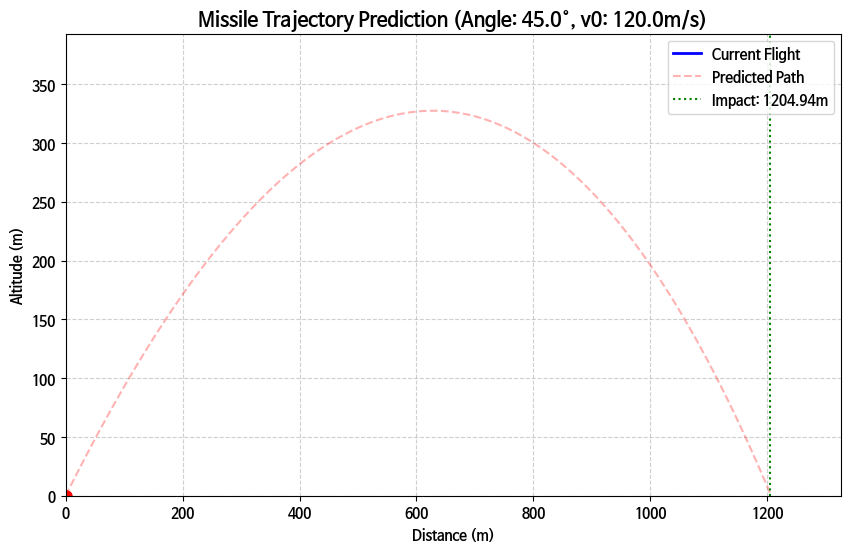

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# --- 1. 시뮬레이션 환경 설정 ---
G = 9.81          # 중력 가속도 (m/s^2)
RHO = 1.225       # 해수면 공기 밀도 (kg/m^3)
CD = 0.47         # 항력 계수 (구형 미사일 기준, 필요시 조정)
AREA = 0.01       # 미사일 단면적 (m^2)
MASS = 15.0       # 미사일 질량 (kg)
DT = 0.05         # 시간 간격 (s)

# 사용자가 입력할 초기 조건 (원하는 대로 수정 가능)
v0 = 120.0        # 초기 속도 (m/s)
angle_deg = 45.0  # 발사 각도 (도)
angle_rad = np.radians(angle_deg)

# --- 2. 물리 연산 엔진 (Euler Method) ---
def get_trajectory(v0, angle_rad, max_steps=2000):
    x, y = [0.0], [0.0]
    vx = v0 * np.cos(angle_rad)
    vy = v0 * np.sin(angle_rad)
    
    for _ in range(max_steps):
        v = np.sqrt(vx**2 + vy**2)
        # 공기 저항력 계산 (F = 0.5 * rho * v^2 * Cd * A)
        f_drag = 0.5 * RHO * v**2 * CD * AREA
        ax = -(f_drag * (vx / v)) / MASS
        ay = -G - (f_drag * (vy / v)) / MASS
        
        vx += ax * DT
        vy += ay * DT
        new_x = x[-1] + vx * DT
        new_y = y[-1] + vy * DT
        
        if new_y < 0: # 땅에 닿으면 종료
            break
        x.append(new_x)
        y.append(new_y)
    return np.array(x), np.array(y)

# 전체 예상 궤적 미리 계산 (예측선용)
full_x, full_y = get_trajectory(v0, angle_rad)
impact_x = full_x[-1]

# --- 3. 실시간 차트 설정 ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, max(full_x) * 1.1)
ax.set_ylim(0, max(full_y) * 1.2)
ax.set_title(f"Missile Trajectory Prediction (Angle: {angle_deg}°, v0: {v0}m/s)", fontsize=14)
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Altitude (m)")
ax.grid(True, linestyle='--', alpha=0.6)

# 그래픽 요소들
curr_line, = ax.plot([], [], 'b-', lw=2, label='Current Flight')  # 실제 비행 경로
pred_line, = ax.plot(full_x, full_y, 'r--', alpha=0.3, label='Predicted Path') # 예측 경로
missile_point, = ax.plot([], [], 'ro', markersize=8) # 미사일 본체
target_mark = ax.axvline(impact_x, color='g', linestyle=':', label=f'Impact: {impact_x:.2f}m')

ax.legend(loc='upper right')

# --- 4. 애니메이션 업데이트 함수 ---
def update(frame):
    if frame < len(full_x):
        curr_line.set_data(full_x[:frame], full_y[:frame])
        missile_point.set_data([full_x[frame]], [full_y[frame]])
    return curr_line, missile_point

# 실행
ani = FuncAnimation(fig, update, frames=range(0, len(full_x), 2), 
                    interval=20, blit=True, repeat=False)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


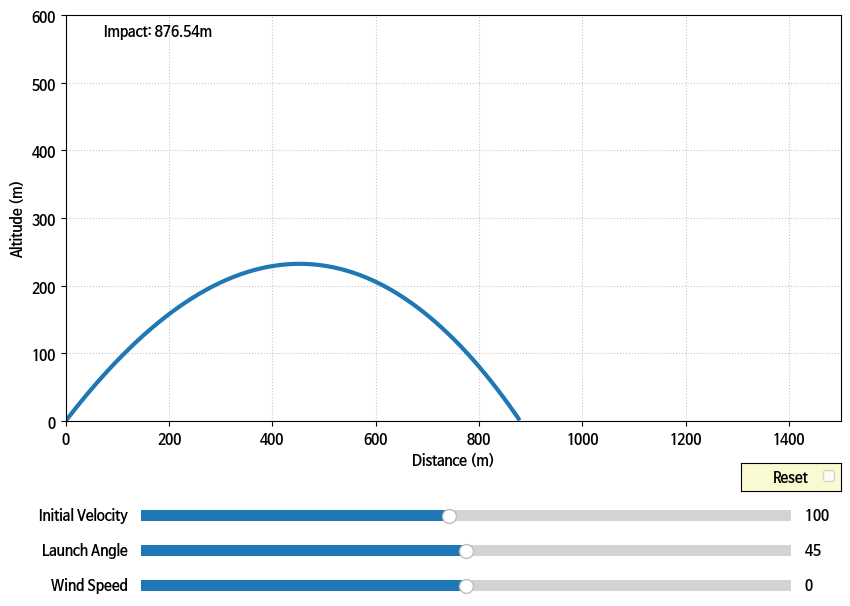

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button

# --- 초기 물리 상수 ---
G = 9.81
RHO = 1.225
CD = 0.47
AREA = 0.01
MASS = 15.0
DT = 0.1

def calculate_trajectory(v0, angle_deg, wind_speed):
    """물리 엔진: 초기 속도, 각도, 풍속을 받아 궤적 계산"""
    angle_rad = np.radians(angle_deg)
    x, y = [0.0], [0.0]
    vx = v0 * np.cos(angle_rad) + wind_speed # 풍속 반영
    vy = v0 * np.sin(angle_rad)
    
    for _ in range(2000):
        v = np.sqrt(vx**2 + vy**2)
        f_drag = 0.5 * RHO * v**2 * CD * AREA
        ax = -(f_drag * (vx / v)) / MASS
        ay = -G - (f_drag * (vy / v)) / MASS
        
        vx += ax * DT
        vy += ay * DT
        new_x = x[-1] + vx * DT
        new_y = y[-1] + vy * DT
        
        if new_y < 0: break
        x.append(new_x)
        y.append(new_y)
    return np.array(x), np.array(y)

# --- 차트 초기 설정 ---
fig, ax = plt.subplots(figsize=(10, 7))
plt.subplots_adjust(bottom=0.3) # 아래쪽에 슬라이더 공간 확보

initial_v0 = 100.0
initial_angle = 45.0
initial_wind = 0.0

x, y = calculate_trajectory(initial_v0, initial_angle, initial_wind)
line, = ax.plot(x, y, lw=3, color='#1f77b4', label='Trajectory')
prediction_text = ax.text(0.05, 0.95, f'Impact: {x[-1]:.2f}m', transform=ax.transAxes)

ax.set_xlim(0, 1500)
ax.set_ylim(0, 600)
ax.grid(True, linestyle=':', alpha=0.7)
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Altitude (m)")

# --- 인터랙티브 슬라이더 (입력부) ---
ax_color = 'lightgoldenrodyellow'
ax_v0 = plt.axes([0.2, 0.15, 0.65, 0.03], facecolor=ax_color)
ax_angle = plt.axes([0.2, 0.1, 0.65, 0.03], facecolor=ax_color)
ax_wind = plt.axes([0.2, 0.05, 0.65, 0.03], facecolor=ax_color)

s_v0 = Slider(ax_v0, 'Initial Velocity', 10.0, 200.0, valinit=initial_v0)
s_angle = Slider(ax_angle, 'Launch Angle', 0.0, 90.0, valinit=initial_angle)
s_wind = Slider(ax_wind, 'Wind Speed', -20.0, 20.0, valinit=initial_wind)

def update(val):
    """슬라이더 값이 바뀌면 즉시 호출되는 함수"""
    v0 = s_v0.val
    angle = s_angle.val
    wind = s_wind.val
    
    new_x, new_y = calculate_trajectory(v0, angle, wind)
    line.set_data(new_x, new_y)
    prediction_text.set_text(f'Impact: {new_x[-1]:.2f}m')
    
    # 궤적에 따라 축 범위 자동 조절 (옵션)
    ax.set_xlim(0, max(max(new_x)*1.1, 500))
    ax.set_ylim(0, max(max(new_y)*1.2, 200))
    
    fig.canvas.draw_idle() # 즉시 다시 그리기

s_v0.on_changed(update)
s_angle.on_changed(update)
s_wind.on_changed(update)

# 리셋 버튼
resetax = plt.axes([0.8, 0.2, 0.1, 0.04])
button = Button(resetax, 'Reset', color=ax_color, hovercolor='0.975')

def reset(event):
    s_v0.reset()
    s_angle.reset()
    s_wind.reset()
button.on_clicked(reset)

plt.legend()
plt.show()

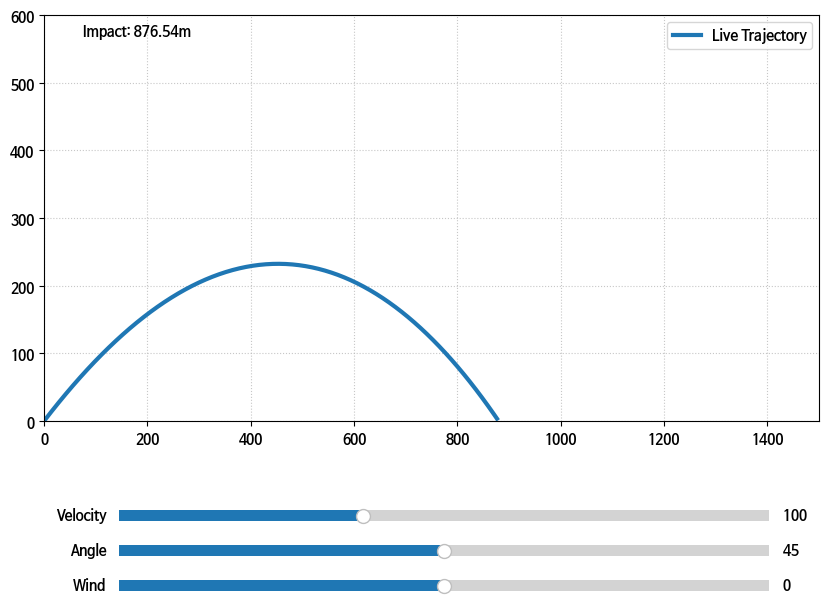

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button

# --- 물리 연산 함수 ---
def calculate_trajectory(v0, angle_deg, wind_speed):
    G, RHO, CD, AREA, MASS, DT = 9.81, 1.225, 0.47, 0.01, 15.0, 0.1
    angle_rad = np.radians(angle_deg)
    x, y = [0.0], [0.0]
    vx = v0 * np.cos(angle_rad) + wind_speed
    vy = v0 * np.sin(angle_rad)
    
    for _ in range(2000):
        v = np.sqrt(vx**2 + vy**2)
        if v == 0: break
        f_drag = 0.5 * RHO * v**2 * CD * AREA
        ax = -(f_drag * (vx / v)) / MASS
        ay = -G - (f_drag * (vy / v)) / MASS
        vx += ax * DT
        vy += ay * DT
        new_x, new_y = x[-1] + vx * DT, y[-1] + vy * DT
        if new_y < 0: break
        x.append(new_x); y.append(new_y)
    return np.array(x), np.array(y)

# --- 메인 대시보드 설정 ---
fig, ax = plt.subplots(figsize=(10, 7))
plt.subplots_adjust(bottom=0.3)

initial_v0, initial_angle, initial_wind = 100.0, 45.0, 0.0
x, y = calculate_trajectory(initial_v0, initial_angle, initial_wind)

# 여기서 label을 확실히 박아줘야 legend가 안 뜸
line, = ax.plot(x, y, lw=3, color='#1f77b4', label='Live Trajectory')
prediction_text = ax.text(0.05, 0.95, f'Impact: {x[-1]:.2f}m', transform=ax.transAxes, weight='bold')

ax.set_xlim(0, 1500); ax.set_ylim(0, 600)
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(loc='upper right') # 이제 에러 안 날 거야

# --- 슬라이더 UI ---
ax_v0 = plt.axes([0.2, 0.15, 0.65, 0.03])
ax_angle = plt.axes([0.2, 0.1, 0.65, 0.03])
ax_wind = plt.axes([0.2, 0.05, 0.65, 0.03])

s_v0 = Slider(ax_v0, 'Velocity', 10.0, 250.0, valinit=initial_v0)
s_angle = Slider(ax_angle, 'Angle', 0.0, 90.0, valinit=initial_angle)
s_wind = Slider(ax_wind, 'Wind', -30.0, 30.0, valinit=initial_wind)

def update(val):
    new_x, new_y = calculate_trajectory(s_v0.val, s_angle.val, s_wind.val)
    line.set_data(new_x, new_y)
    prediction_text.set_text(f'Impact: {new_x[-1]:.2f}m')
    
    # 궤적에 따라 축 가변 조절 (더 다이내믹함)
    ax.set_xlim(0, max(max(new_x)*1.1, 500))
    ax.set_ylim(0, max(max(new_y)*1.2, 200))
    fig.canvas.draw_idle()

s_v0.on_changed(update)
s_angle.on_changed(update)
s_wind.on_changed(update)

plt.show()

🚀 미사일 시뮬레이션 초기 설정 (Rhee Hose System)
형식 예시: 초기 속도는 100, 각도는 45, 풍속은 0 (숫자만 입력)


입력 1) 초기 속도 (m/s) [ex: 120]:  500
입력 2) 발사 각도 (degree) [ex: 45]:  90
입력 3) 현재 풍속 (m/s, 역풍은 마이너스) [ex: 5]:  3



✅ 대시보드가 활성화되었습니다. 슬라이더로 실시간 조절이 가능합니다.


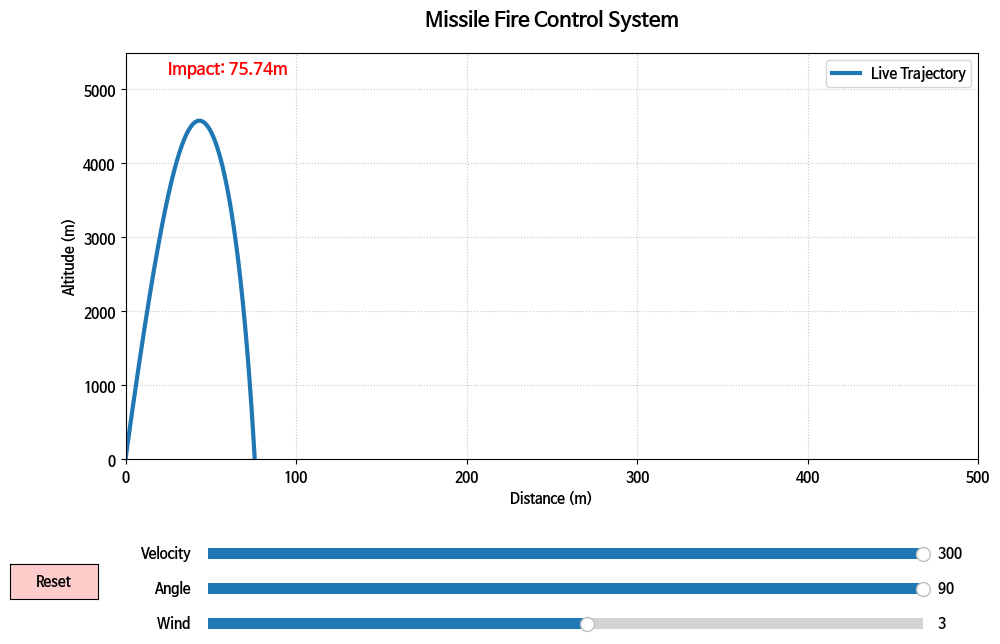

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button

# --- 1. 터미널 입력부 (실행 시 가장 먼저 나타남) ---
print("="*50)
print("🚀 미사일 시뮬레이션 초기 설정 (Rhee Hose System)")
print("="*50)
print("형식 예시: 초기 속도는 100, 각도는 45, 풍속은 0 (숫자만 입력)")

try:
    user_v0 = float(input("입력 1) 초기 속도 (m/s) [ex: 120]: ") or 120)
    user_angle = float(input("입력 2) 발사 각도 (degree) [ex: 45]: ") or 45)
    user_wind = float(input("입력 3) 현재 풍속 (m/s, 역풍은 마이너스) [ex: 5]: ") or 0)
except ValueError:
    print("⚠️ 숫자만 입력하라고 했잖아! 기본값(100, 45, 0)으로 시작한다.")
    user_v0, user_angle, user_wind = 100.0, 45.0, 0.0

# --- 2. 물리 연산 엔진 ---
def calculate_trajectory(v0, angle_deg, wind_speed):
    G, RHO, CD, AREA, MASS, DT = 9.81, 1.225, 0.47, 0.01, 15.0, 0.1
    angle_rad = np.radians(angle_deg)
    x, y = [0.0], [0.0]
    # 단순화된 풍속 반영 (x축 속도에 영향)
    vx = v0 * np.cos(angle_rad) + wind_speed
    vy = v0 * np.sin(angle_rad)
    
    for _ in range(2500):
        v = np.sqrt(vx**2 + vy**2)
        if v == 0: break
        f_drag = 0.5 * RHO * v**2 * CD * AREA
        ax = -(f_drag * (vx / v)) / MASS
        ay = -G - (f_drag * (vy / v)) / MASS
        
        vx += ax * DT
        vy += ay * DT
        new_x = x[-1] + vx * DT
        new_y = y[-1] + vy * DT
        
        if new_y < 0: break
        x.append(new_x)
        y.append(new_y)
    return np.array(x), np.array(y)

# --- 3. 대시보드 시각화 설정 ---
fig, ax = plt.subplots(figsize=(11, 7))
plt.subplots_adjust(bottom=0.3)

# 초기 데이터 계산
x, y = calculate_trajectory(user_v0, user_angle, user_wind)
line, = ax.plot(x, y, lw=3, color='#1f77b4', label='Live Trajectory')
prediction_text = ax.text(0.05, 0.95, f'Impact: {x[-1]:.2f}m', 
                          transform=ax.transAxes, weight='bold', fontsize=12, color='red')

# 그래프 스타일링
ax.set_xlim(0, max(max(x)*1.2, 500))
ax.set_ylim(0, max(max(y)*1.2, 200))
ax.grid(True, linestyle=':', alpha=0.7)
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Altitude (m)")
ax.set_title("Missile Fire Control System", fontsize=15, pad=20)
ax.legend(loc='upper right')

# --- 4. 슬라이더 UI (인터랙티브 제어) ---
ax_color = '#f0f0f0'
ax_v0 = plt.axes([0.2, 0.15, 0.65, 0.03], facecolor=ax_color)
ax_angle = plt.axes([0.2, 0.1, 0.65, 0.03], facecolor=ax_color)
ax_wind = plt.axes([0.2, 0.05, 0.65, 0.03], facecolor=ax_color)

s_v0 = Slider(ax_v0, 'Velocity ', 10.0, 300.0, valinit=user_v0)
s_angle = Slider(ax_angle, 'Angle ', 0.0, 90.0, valinit=user_angle)
s_wind = Slider(ax_wind, 'Wind ', -50.0, 50.0, valinit=user_wind)

def update(val):
    v = s_v0.val
    a = s_angle.val
    w = s_wind.val
    
    new_x, new_y = calculate_trajectory(v, a, w)
    line.set_data(new_x, new_y)
    prediction_text.set_text(f'Impact: {new_x[-1]:.2f}m')
    
    # 궤적 크기에 따라 축 자동 최적화
    ax.set_xlim(0, max(max(new_x)*1.1, 500))
    ax.set_ylim(0, max(max(new_y)*1.1, 100))
    fig.canvas.draw_idle()

s_v0.on_changed(update)
s_angle.on_changed(update)
s_wind.on_changed(update)

# 초기화 버튼
resetax = plt.axes([0.02, 0.1, 0.08, 0.05])
button = Button(resetax, 'Reset', color='#ffcccc', hovercolor='0.975')

def reset(event):
    s_v0.reset()
    s_angle.reset()
    s_wind.reset()
button.on_clicked(reset)

print("\n✅ 대시보드가 활성화되었습니다. 슬라이더로 실시간 조절이 가능합니다.")
plt.show()


🛡️  RHEE HOSE TACTICAL FIRE CONTROL SYSTEM v2.0
💡 입력을 건너뛰려면 엔터를 누르세요 (Default 값 적용)


▶ 발사 초속 (m/s) [ex: 800 (초음속)]:  800
▶ 발사 각도 (deg) [ex: 35]:  60
▶ 미사일 초기 질량 (kg) [ex: 50]:  100
▶ 측풍 풍속 (m/s) [ex: -10]:  3



[SYSTEM] 사격 통제 터미널 가동 중... 그래프 창을 확인하십시오.


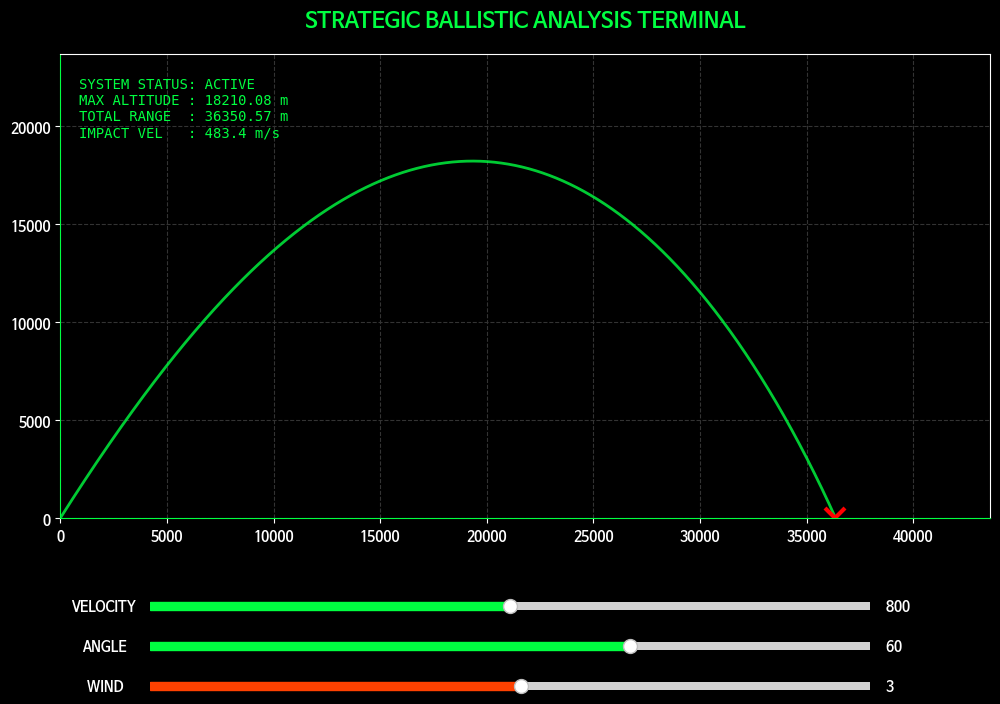

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button

# --- 1. 터미널 입력부 (초기 설정) ---
print("\n" + "="*60)
print("🛡️  RHEE HOSE TACTICAL FIRE CONTROL SYSTEM v2.0")
print("="*60)
print("💡 입력을 건너뛰려면 엔터를 누르세요 (Default 값 적용)")

try:
    init_v = float(input("▶ 발사 초속 (m/s) [ex: 800 (초음속)]: ") or 800)
    init_a = float(input("▶ 발사 각도 (deg) [ex: 35]: ") or 35)
    init_m = float(input("▶ 미사일 초기 질량 (kg) [ex: 50]: ") or 50)
    init_w = float(input("▶ 측풍 풍속 (m/s) [ex: -10]: ") or 0)
except ValueError:
    print("❌ 수치 입력 오류! 시스템 기본값으로 강제 리부팅합니다.")
    init_v, init_a, init_m, init_w = 500, 45, 100, 0

# --- 2. 하드코어 물리 엔진 (극사실주의) ---
def calculate_hardcore_trajectory(v0, angle_deg, wind_p, mass_init):
    # 상수 설정
    G = 9.80665
    DT = 0.05
    BURN_RATE = 0.8     # 초당 연료 소모량 (kg/s)
    FUEL_MASS = mass_init * 0.4 # 전체 질량의 40%가 연료
    THRUST = 1500.0     # 초기 추진력 (N)
    THRUST_DURATION = 5.0 # 5초간 엔진 점화
    
    angle_rad = np.radians(angle_deg)
    x, y = [0.0], [0.0]
    vx = v0 * np.cos(angle_rad) + wind_p
    vy = v0 * np.sin(angle_rad)
    curr_mass = mass_init
    t = 0
    
    for _ in range(5000):
        v_mag = np.sqrt(vx**2 + vy**2)
        if v_mag == 0: break
        
        # [사실 1] 고도(y)에 따른 공기 밀도 변화 (Barometric formula 적용)
        rho = 1.225 * np.exp(-y[-1] / 8500.0) 
        
        # [사실 2] 마하 수에 따른 항력 계수(Cd) 가변 (간략화된 초음속 모델)
        mach = v_mag / 340.0
        cd = 0.2 if mach < 0.8 else (0.5 if mach < 1.2 else 0.3)
        
        drag = 0.5 * rho * v_mag**2 * cd * 0.02 # 단면적 0.02
        
        # [사실 3] 연료 소모 및 추진력 반영
        current_thrust = THRUST if t < THRUST_DURATION and curr_mass > (mass_init - FUEL_MASS) else 0
        if current_thrust > 0:
            curr_mass -= BURN_RATE * DT
            
        # 가속도 계산 (F = ma -> a = F/m)
        ax = (current_thrust * (vx/v_mag) - drag * (vx/v_mag)) / curr_mass
        ay = (-curr_mass * G + current_thrust * (vy/v_mag) - drag * (vy/v_mag)) / curr_mass
        
        vx += ax * DT
        vy += ay * DT
        new_x, new_y = x[-1] + vx * DT, y[-1] + vy * DT
        
        if new_y < 0: break
        x.append(new_x); y.append(new_y)
        t += DT
        
    return np.array(x), np.array(y)

# --- 3. 그래프 스타일링 (Dark/Tactical Mode) ---
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 8))
plt.subplots_adjust(bottom=0.3)

x, y = calculate_hardcore_trajectory(init_v, init_a, init_w, init_m)
line, = ax.plot(x, y, color='#00FF41', lw=2, label='TRACED PATH', alpha=0.8) # 매트릭스 그린
impact_ptr, = ax.plot(x[-1], 0, 'rx', markersize=15, markeredgewidth=3, label='IMPACT ZONE')

# 텍스트 정보창
info_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, color='#00FF41', 
                    fontfamily='monospace', fontsize=10, verticalalignment='top')

def update_text(x_val, y_val):
    txt = (f"SYSTEM STATUS: ACTIVE\n"
           f"MAX ALTITUDE : {max(y_val):.2f} m\n"
           f"TOTAL RANGE  : {x_val[-1]:.2f} m\n"
           f"IMPACT VEL   : {np.sqrt((x_val[-1]-x_val[-2])**2 + y_val[-2]**2)/0.1:.1f} m/s")
    info_text.set_text(txt)

update_text(x, y)

ax.set_xlim(0, max(x)*1.2); ax.set_ylim(0, max(y)*1.3)
ax.grid(color='#333333', linestyle='--')
ax.set_title("STRATEGIC BALLISTIC ANALYSIS TERMINAL", color='#00FF41', fontsize=16, pad=20)
ax.spines['bottom'].set_color('#00FF41')
ax.spines['left'].set_color('#00FF41')

# --- 4. 슬라이더 (실시간 제어) ---
s_ax_v = plt.axes([0.2, 0.18, 0.6, 0.02], facecolor='#111111')
s_ax_a = plt.axes([0.2, 0.13, 0.6, 0.02], facecolor='#111111')
s_ax_w = plt.axes([0.2, 0.08, 0.6, 0.02], facecolor='#111111')

sl_v = Slider(s_ax_v, 'VELOCITY', 100, 1500, valinit=init_v, color='#00FF41')
sl_a = Slider(s_ax_a, 'ANGLE   ', 0, 90, valinit=init_a, color='#00FF41')
sl_w = Slider(s_ax_w, 'WIND    ', -100, 100, valinit=init_w, color='#FF4100')

def sync_update(val):
    nx, ny = calculate_hardcore_trajectory(sl_v.val, sl_a.val, sl_w.val, init_m)
    line.set_data(nx, ny)
    impact_ptr.set_data([nx[-1]], [0])
    ax.set_xlim(0, max(nx)*1.2); ax.set_ylim(0, max(ny)*1.3)
    update_text(nx, ny)
    fig.canvas.draw_idle()

sl_v.on_changed(sync_update); sl_a.on_changed(sync_update); sl_w.on_changed(sync_update)

print("\n[SYSTEM] 사격 통제 터미널 가동 중... 그래프 창을 확인하십시오.")
plt.show()

# 🚀 RHEE HOSE TACTICAL FIRE CONTROL SYSTEM: Technical Specification

이 문서된 파이썬 기반 **극사실주의 미사일 탄도 시뮬레이션 및 실시간 사격 통제 시스템**의 설계 사양과 물리 엔진 알고리즘을 상세히 설명합니다.

---

## 1. 시스템 개요 (System Overview)
본 시스템은 단순한 포물선 운동(Parabolic Motion)을 넘어, 대기 역학 및 고도에 따른 환경 변화를 실시간으로 연산하는 **고정밀 탄도 분석 터미널**입니다. `Matplotlib`의 인터랙티브 위젯을 활용하여 사용자의 입력값 변경에 즉각적으로 반응하는 대시보드 형태를 취하고 있습니다.

---

## 2. 하드코어 물리 엔진 알고리즘 (Physics Engine)

시스템의 핵심은 **오일러 방법(Euler Method)**을 이용한 수치 해석이며, 다음과 같은 물리적 변수를 실시간으로 통합 연산합니다.

### 2.1 대기 밀도 가변 모델 (Atmospheric Density)
고도($y$)가 높아질수록 대기 밀도($\rho$)가 지수 함수적으로 감소하는 현상을 반영합니다.
$$\rho(y) = \rho_0 \cdot e^{-\frac{y}{H}}$$
* $\rho_0$: 해수면 밀도 ($1.225 \, kg/m^3$)
* $H$: 스케일 높이 ($\approx 8500 \, m$)

### 2.2 가변 항력 계수 및 마하 수 (Drag Coefficient & Mach Number)
탄체가 음속($340 \, m/s$)에 도달할 때 발생하는 소닉 붐과 저항 급증을 시뮬레이션합니다.
* **Subsonic ($M < 0.8$):** 낮은 항력 ($C_d \approx 0.2$)
* **Transonic ($0.8 \le M < 1.2$):** 급격한 저항 상승 ($C_d \approx 0.5$)
* **Supersonic ($M \ge 1.2$):** 충격파 형성 후 안정화 ($C_d \approx 0.3$)

### 2.3 질량 가변 및 추진력 시스템 (Variable Mass & Thrust)
연료 소모에 따라 미사일이 가벼워지며 가속도가 증가하는 현상을 구현합니다.
* **Initial Thrust:** 초기 5초간 강력한 추진력($1500N$) 제공
* **Mass Reduction:** 연료 연소율($0.8kg/s$)에 따른 실시간 질량($m$) 업데이트



---

## 3. UI/UX 및 시각화 스타일링 (Visualization)

리눅스 개발자 감성과 군사 작전 터미널의 시인성을 결합한 **Tactical Dark Mode**를 채택했습니다.

| 요소 | 사양 | 비고 |
| :--- | :--- | :--- |
| **컬러 스킴** | `#00FF41` (Matrix Green) | 높은 대비와 몰입감 제공 |
| **폰트** | Monospace | 터미널 로그 및 데이터 가독성 최적화 |
| **실시간 위젯** | `Slider`, `Button` | 매끄러운 입력값($v_0, \theta, wind$) 보정 |
| **착탄 표식** | Red Cross (`X`) | 최종 타격 지점 시각적 강조 |

---

## 4. 실시간 데이터 스트리밍 (Real-time Feedback)

사용자가 슬라이더를 조절할 때마다 시스템은 다음 데이터를 즉시 재계산하여 출력합니다.
1.  **MAX ALTITUDE:** 탄체가 도달하는 최고 정점 고도
2.  **TOTAL RANGE:** 발사 지점으로부터 최종 착탄 지점까지의 수평 거리
3.  **IMPACT VELOCITY:** 지표면 충돌 순간의 최종 속도 (파괴력 산출 기초 데이터)

---

## 5. 실행 및 의존성 (E이 파이썬 순정 라이브러리만으로 구동됩니다.
* **OS:** Linux Mint (Recommended)
* **Language:** Python 3.x
* **Dependencies:** `numpy`, `matplotlib`

---
**NOTICE:** *본 시뮬레이션은 교육 및 연구용으로 제작되었으며, 실제 전술 데이터와는 환경 변수 설정에 따라 차이가 있을 수 있습니다.*


☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  
STRATEGIC NUCLEAR IMPACT ANALYSIS TERMINAL v3.1
SYSTEM STATUS: READY FOR TARGETING
☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  


▶ 대상 도시 명칭 [ex: Seoul]:  Seoul
▶ 대상 도시 인구 수 (명) [ex: 9500000]:  9500000
▶ 탄두 위력 수치 [ex: 800]:  800
▶ 위력 단위 (kt / mt / t) [ex: kt]:  mt



[SYSTEM] 시뮬레이션 차트가 생성되었습니다. 인터페이스를 조작하십시오.


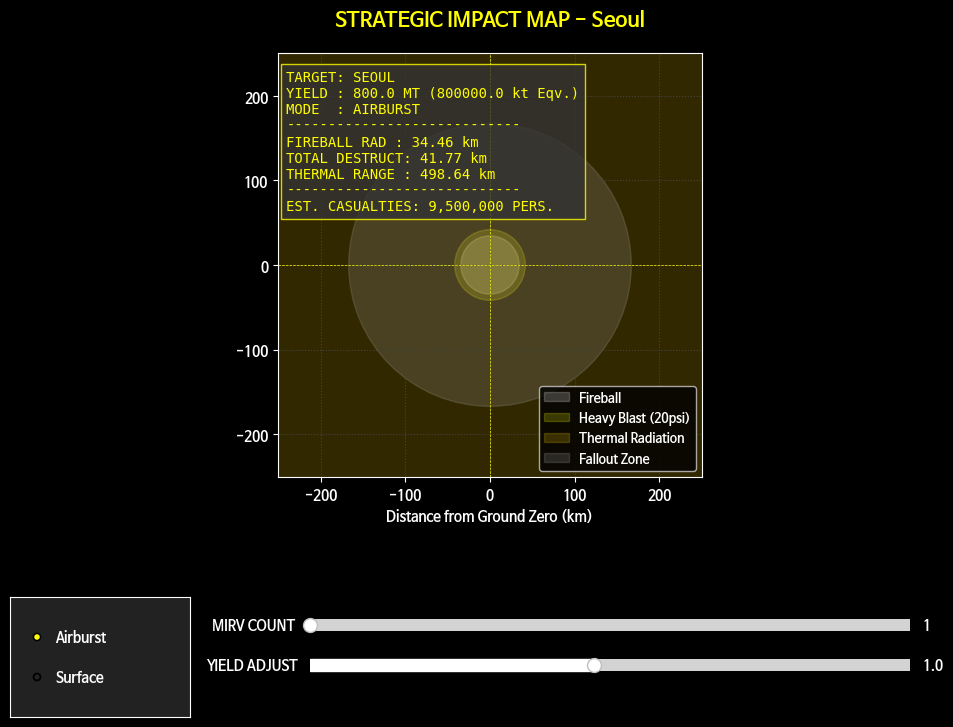

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, RadioButtons, TextBox

# --- 1. 터미널 입력부 (사전 설정) ---
print("\n" + "☢️  "*15)
print("STRATEGIC NUCLEAR IMPACT ANALYSIS TERMINAL v3.1")
print("SYSTEM STATUS: READY FOR TARGETING")
print("☢️  "*15)

try:
    target_city = input("▶ 대상 도시 명칭 [ex: Seoul]: ") or "Unknown City"
    city_pop = float(input("▶ 대상 도시 인구 수 (명) [ex: 9500000]: ") or 9500000)
    yield_val = float(input("▶ 탄두 위력 수치 [ex: 800]: ") or 800)
    yield_unit = input("▶ 위력 단위 (kt / mt / t) [ex: kt]: ").lower() or "kt"
except ValueError:
    print("⚠️ 데이터 해석 오류. 기본값(800kt, Seoul)으로 강제 로드합니다.")
    target_city, city_pop, yield_val, yield_unit = "Seoul", 9500000, 800, "kt"

# 위력 단위를 kt로 표준화 (에너지 환산용)
if yield_unit == "mt": yield_kt = yield_val * 1000
elif yield_unit == "t": yield_kt = yield_val / 1000
else: yield_kt = yield_val

# --- 2. 핵폭발 물리 모델 (Scaling Laws) ---
def get_blast_radii(kt, burst_type):
    """
    공중폭발(Airburst)과 지상타격(Surface)의 피해 반경 계산 (Empirical Scaling)
    반경 = 상수 * kt^(1/3)
    """
    modifier = 1.0 if burst_type == 'Airburst' else 0.75
    
    # 1. 화구(Fireball) 반경
    r_fireball = 0.15 * (kt**0.4) * modifier
    # 2. 치명적 과압 (20 psi, 콘크리트 건물 완파)
    r_heavy = 0.45 * (kt**(1/3)) * modifier
    # 3. 열복사 (3도 화상, 가연물 발화)
    r_thermal = 1.1 * (kt**0.45) * modifier
    # 4. 방사능 낙진 예상 범위 (간략화)
    r_fallout = 1.8 * (kt**(1/3)) * modifier
    
    return [r_fireball, r_heavy, r_thermal, r_fallout]

# --- 3. 시각화 엔진 (Dark Grey / Yellow / White) ---
plt.style.use('dark_background')
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111)
plt.subplots_adjust(left=0.1, bottom=0.35)

# 초기 물리 계산
radii = get_blast_radii(yield_kt, 'Airburst')
colors = ['#FFFFFF', '#FFFF00', '#FFCC00', '#AAAAAA'] # White, Yellow, Deep Yellow, Grey
labels = ['Fireball', 'Heavy Blast (20psi)', 'Thermal Radiation', 'Fallout Zone']

circles = []
for r, c, l in zip(radii, colors, labels):
    circle = plt.Circle((0, 0), r, color=c, alpha=0.2, label=l)
    ax.add_artist(circle)
    circles.append(circle)
    # 테두리
    ax.plot([], [], color=c, lw=1.5) 

# 타겟팅 라인 (Crosshair)
ax.axhline(0, color='#FFFF00', lw=0.5, ls='--')
ax.axvline(0, color='#FFFF00', lw=0.5, ls='--')

# 텍스트 정보창
info_box = ax.text(0.02, 0.96, '', transform=ax.transAxes, color='#FFFF00', 
                   fontfamily='monospace', fontsize=10, verticalalignment='top',
                   bbox=dict(facecolor='#333333', alpha=0.8, edgecolor='#FFFF00'))

def update_info(kt, b_type):
    r = get_blast_radii(kt, b_type)
    area = np.pi * (r[2]**2) # 열복사 반경 기준 피해 면적
    est_casualty = min(city_pop, (area / 100) * (city_pop / 50)) # 매우 간략화된 추정치
    
    txt = (f"TARGET: {target_city.upper()}\n"
           f"YIELD : {yield_val} {yield_unit.upper()} ({kt:.1f} kt Eqv.)\n"
           f"MODE  : {b_type.upper()}\n"
           f"----------------------------\n"
           f"FIREBALL RAD : {r[0]:.2f} km\n"
           f"TOTAL DESTRUCT: {r[1]:.2f} km\n"
           f"THERMAL RANGE : {r[2]:.2f} km\n"
           f"----------------------------\n"
           f"EST. CASUALTIES: {int(est_casualty):,} PERS.")
    info_box.set_text(txt)

update_info(yield_kt, 'Airburst')

# 그래프 스타일
ax.set_aspect('equal')
limit = radii[3] * 1.5
ax.set_xlim(-limit, limit); ax.set_ylim(-limit, limit)
ax.set_title(f"STRATEGIC IMPACT MAP - {target_city}", color='#FFFF00', fontsize=15, pad=20)
ax.set_xlabel("Distance from Ground Zero (km)", color='#FFFFFF')
ax.grid(True, color='#444444', linestyle=':')
ax.legend(loc='lower right', fontsize=9)

# --- 4. 인터랙티브 컨트롤부 ---
# 1. 폭발 방식 선택
rax = plt.axes([0.1, 0.05, 0.15, 0.15], facecolor='#222222')
radio = RadioButtons(rax, ('Airburst', 'Surface'), activecolor='#FFFF00')

# 2. 다탄두(MIRV) 시뮬레이션 (위력 분산 효과)
s_mirv_ax = plt.axes([0.35, 0.15, 0.5, 0.03], facecolor='#222222')
s_mirv = Slider(s_mirv_ax, 'MIRV COUNT ', 1, 12, valinit=1, valstep=1, color='#FFFF00')

# 3. 위력 미세 조정 (Yield Slider)
s_yield_ax = plt.axes([0.35, 0.1, 0.5, 0.03], facecolor='#222222')
s_yield = Slider(s_yield_ax, 'YIELD ADJUST', 0.1, 2.0, valinit=1.0, color='#FFFFFF')

def update_sim(val):
    current_b_type = radio.value_selected
    # 다탄두 시 탄두당 위력 분산 (단순 모델)
    adjusted_kt = (yield_kt * s_yield.val) / s_mirv.val
    new_radii = get_blast_radii(adjusted_kt, current_b_type)
    
    for circle, r in zip(circles, new_radii):
        circle.set_radius(r)
    
    # 다탄두일 경우 시각적으로 탄두 수 표시 (옵션)
    ax.set_title(f"STRATEGIC IMPACT MAP - {target_city} ({int(s_mirv.val)} MIRVs)", color='#FFFF00')
    
    update_info(adjusted_kt * s_mirv.val, current_b_type)
    limit = max(new_radii) * 2
    ax.set_xlim(-limit, limit); ax.set_ylim(-limit, limit)
    fig.canvas.draw_idle()

radio.on_clicked(update_sim)
s_mirv.on_changed(update_sim)
s_yield.on_changed(update_sim)

print("\n[SYSTEM] 시뮬레이션 차트가 생성되었습니다. 인터페이스를 조작하십시오.")
plt.show()


☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  
계획된 전략 핵타격 피해 분석 터미널 v4.1 (Fixed)
시스템 상태: 타겟팅 대기 중...
☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  ☢️  


▶ 대상 도시 명칭 [기본: 서울]:  서울
▶ 대상 도시 인구 [기본: 9500000]:  9500000
▶ 탄두 위력 수치 [기본: 800]:  100
▶ 단위 (kt / mt / t) [기본: kt]:  



[SYSTEM] 분석 터미널이 가동되었습니다.


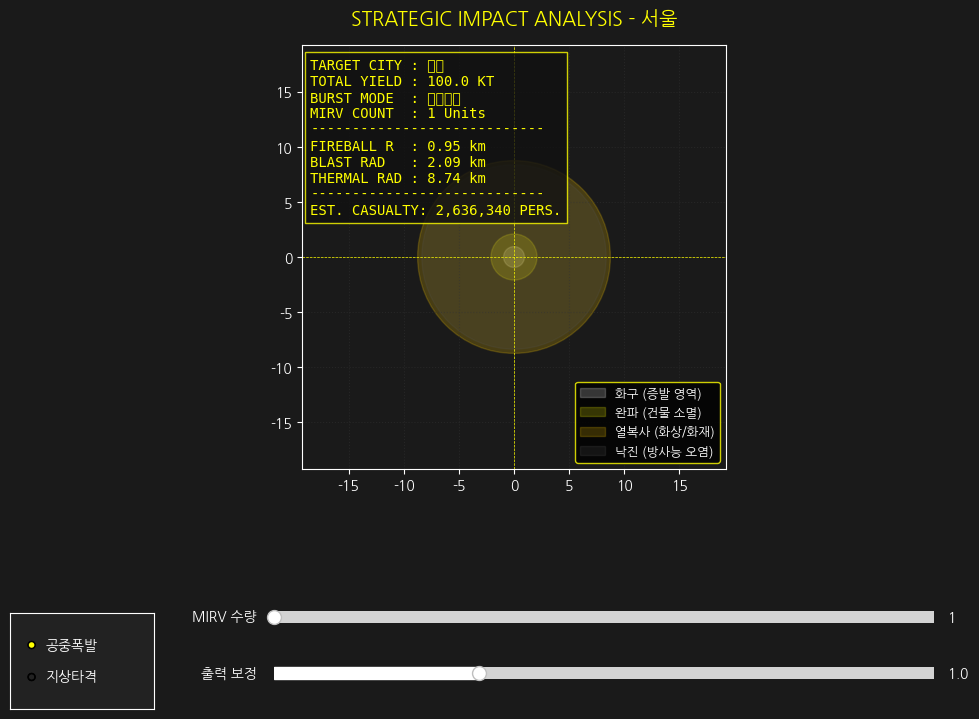

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, RadioButtons
import matplotlib.font_manager as fm

# --- 1. 한글 폰트 설정 (에러 방지용 명시적 로드) ---
try:
    # 나눔고딕이 있으면 쓰고, 없으면 시스템 기본 폰트 사용
    font_names = [f.name for f in fm.fontManager.ttflist]
    if 'NanumGothic' in font_names:
        plt.rcParams['font.family'] = 'NanumGothic'
    elif 'Nanum Barun Gothic' in font_names:
        plt.rcParams['font.family'] = 'Nanum Barun Gothic'
    else:
        plt.rcParams['font.family'] = 'sans-serif'
except Exception:
    plt.rcParams['font.family'] = 'sans-serif'

plt.rcParams['axes.unicode_minus'] = False

# --- 2. 초기 데이터 입력 (Terminal Input) ---
print("\n" + "☢️  " * 15)
print("계획된 전략 핵타격 피해 분석 터미널 v4.1 (Fixed)")
print("시스템 상태: 타겟팅 대기 중...")
print("☢️  " * 15)

try:
    city_name = input("▶ 대상 도시 명칭 [기본: 서울]: ") or "서울"
    pop_total = float(input("▶ 대상 도시 인구 [기본: 9500000]: ") or 9500000)
    yield_val = float(input("▶ 탄두 위력 수치 [기본: 800]: ") or 800)
    unit = input("▶ 단위 (kt / mt / t) [기본: kt]: ").lower() or "kt"
except ValueError:
    print("⚠️ 입력 오류! 기본 데이터로 복구합니다.")
    city_name, pop_total, yield_val, unit = "서울", 9500000, 800, "kt"

# 위력 단위 표준화 (kt 기준)
if unit == "mt": yield_kt = yield_val * 1000
elif unit == "t": yield_kt = yield_val / 1000
else: yield_kt = yield_val

# --- 3. 핵폭발 물리 모델 (Scaling Laws) ---
def get_radii(kt, mode):
    # 공중폭발 vs 지상타격 효율 차이 반영 (m: 조정 계수)
    m = 1.0 if mode == '공중폭발' else 0.75
    # 결과: [화구, 완파(20psi), 열복사(3도화상), 낙진경계]
    return [
        0.15 * (kt**0.4) * m, 
        0.45 * (kt**(1/3)) * m, 
        1.1 * (kt**0.45) * m, 
        1.8 * (kt**(1/3)) * m
    ]

# --- 4. 시각화 엔진 설정 (Dark Grey / Yellow / White) ---
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#1A1A1A') # 짙은 회색 배경
ax.set_facecolor('#1A1A1A')
plt.subplots_adjust(left=0.08, bottom=0.35, right=0.92)

# 초기 물리 계산
init_radii = get_radii(yield_kt, '공중폭발')
colors = ['#FFFFFF', '#FFFF00', '#FFCC00', '#555555'] # White, Yellow, Gold, Grey
labels = ['화구 (증발 영역)', '완파 (건물 소멸)', '열복사 (화상/화재)', '낙진 (방사능 오염)']

circles = []
for r, c, l in zip(init_radii, colors, labels):
    circle = plt.Circle((0, 0), r, color=c, alpha=0.2, label=l)
    ax.add_artist(circle)
    circles.append(circle)
    # 테두리 선 추가
    ax.plot([], [], color=c, lw=1.5, ls='-', alpha=0.8)

# 차트 디테일 (십자선 및 그리드)
ax.set_aspect('equal')
ax.axhline(0, color='#FFFF00', lw=0.5, ls='--')
ax.axvline(0, color='#FFFF00', lw=0.5, ls='--')
ax.grid(True, color='#333333', linestyle=':', alpha=0.5)

# 정보 출력창 (텍스트 박스)
info_box = ax.text(0.02, 0.97, '', transform=ax.transAxes, color='#FFFF00', 
                   fontfamily='monospace', fontsize=10, verticalalignment='top',
                   bbox=dict(facecolor='#111111', edgecolor='#FFFF00', alpha=0.8))

def update_display(kt, mode, mirv_count):
    # 다탄두 시 탄두 1기당 위력으로 계산
    unit_kt = kt / mirv_count
    r = get_radii(unit_kt, mode)
    
    # 피해 면적 계산 (열복사 반경 기준)
    total_area = (np.pi * (r[2]**2)) * mirv_count
    # 인구 밀도 기반 매우 단순화된 사상자 추정 (1km2 당 인구수 활용)
    density = pop_total / 605 # 서울 면적 기준 대략적 밀도
    est_casualty = min(pop_total, total_area * density * 0.7) 
    
    txt = (f"TARGET CITY : {city_name}\n"
           f"TOTAL YIELD : {yield_val} {unit.upper()}\n"
           f"BURST MODE  : {mode}\n"
           f"MIRV COUNT  : {int(mirv_count)} Units\n"
           f"----------------------------\n"
           f"FIREBALL R  : {r[0]:.2f} km\n"
           f"BLAST RAD   : {r[1]:.2f} km\n"
           f"THERMAL RAD : {r[2]:.2f} km\n"
           f"----------------------------\n"
           f"EST. CASUALTY: {int(est_casualty):,} PERS.")
    info_box.set_text(txt)
    
    limit = max(r) * 2.2
    ax.set_xlim(-limit, limit); ax.set_ylim(-limit, limit)
    ax.set_title(f"STRATEGIC IMPACT ANALYSIS - {city_name}", color='#FFFF00', fontsize=14, pad=15)

update_display(yield_kt, '공중폭발', 1)

# --- 5. 인터랙티브 제어 위젯 ---
# 1. 폭발 모드 라디오 버튼
ax_mode = plt.axes([0.08, 0.05, 0.12, 0.12], facecolor='#222222')
radio = RadioButtons(ax_mode, ('공중폭발', '지상타격'), activecolor='#FFFF00')
for label in radio.labels:
    label.set_color('#FFFFFF')

# 2. 다탄두(MIRV) 슬라이더
ax_mirv = plt.axes([0.3, 0.15, 0.55, 0.03], facecolor='#222222')
s_mirv = Slider(ax_mirv, 'MIRV 수량 ', 1, 12, valinit=1, valstep=1, color='#FFFF00')
s_mirv.label.set_color('#FFFFFF')

# 3. 위력 미세 조정 슬라이더
ax_yield = plt.axes([0.3, 0.08, 0.55, 0.03], facecolor='#222222')
s_yield = Slider(ax_yield, '출력 보정 ', 0.1, 3.0, valinit=1.0, color='#FFFFFF')
s_yield.label.set_color('#FFFFFF')

def update_all(val):
    current_mode = radio.value_selected
    m_count = s_mirv.val
    adj_kt = yield_kt * s_yield.val
    
    # 탄두당 물리 반경 재계산
    new_r = get_radii(adj_kt / m_count, current_mode)
    for circ, r_val in zip(circles, new_r):
        circ.set_radius(r_val)
    
    update_display(adj_kt, current_mode, m_count)
    fig.canvas.draw_idle()

radio.on_clicked(update_all)
s_mirv.on_changed(update_all)
s_yield.on_changed(update_all)

ax.legend(loc='lower right', frameon=True, edgecolor='#FFFF00', fontsize=9)
print("\n[SYSTEM] 분석 터미널이 가동되었습니다.")
plt.show()